In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
#from scripts.experiments import ModelEvaluator
from utils.plot_function import *
raw_data_path = 'P:/3026008.02/rawData/'
data_path = 'P:/3026008.02/AllData/'
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20, 25]

# Uni-sensory trials

**Goal**
for each condition, perceptual spatial bias as a function of CI

In [17]:
#data preparation
df_uni_A = pd.DataFrame()
df_uni_V = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    # filter out the unisensory data
    sub_uniA_data = subA_data[subA_data['Vis Loc'].isna()].reset_index(drop=True)
    sub_uniA_data['sub_id'] = sub_id
    sub_uniA_data['Modality'] = 'A'
    sub_uniA_data['stim_loc'] = sub_uniA_data['Aud Loc']
    sub_uniA_data['Vis Rel'] = 0 # reassign the visual reliability to 0 for uni-sensory auditory blocks
    sub_uniV_data = subV_data[subV_data['Aud Loc'].isna()].reset_index(drop=True)
    sub_uniV_data['sub_id'] = sub_id
    sub_uniV_data['Modality'] = 'V'
    sub_uniV_data['stim_loc'] = sub_uniV_data['Vis Loc']
     # concatenate the data
    df_uni_V = pd.concat([df_uni_V, sub_uniV_data], ignore_index=True)
    df_uni_A = pd.concat([df_uni_A, sub_uniA_data], ignore_index=True)

In [18]:
df_uni_A.head()

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc
0,1,1,-5,NaN,0,-3.59,6.49,NaN,NaN,2,A,-5
1,1,13,0,NaN,0,-4.15,5.15,NaN,NaN,2,A,0
2,1,25,10,NaN,0,8.59,5.71,NaN,NaN,2,A,10
3,1,27,5,NaN,0,5.60,5.34,NaN,NaN,2,A,5
4,1,28,-10,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10


In [19]:
df_uni_V.describe()

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,stim_loc
count,960.000000,960.000000,0.0,960.000000,960.000000,960.000000,960.000000,0.0,0.0,960.000000,960.000000
mean,2.500000,90.638542,NaN,0.000000,1.500000,0.295687,5.371958,NaN,NaN,10.875000,0.000000
std,1.118617,52.104867,NaN,7.074754,0.500261,6.284621,2.903091,NaN,NaN,7.900911,7.074754
min,1.000000,1.000000,NaN,-10.000000,1.000000,-13.890000,0.440000,NaN,NaN,2.000000,-10.000000
25%,1.750000,45.000000,NaN,-5.000000,1.000000,-4.820000,3.360000,NaN,NaN,4.500000,-5.000000
50%,2.500000,90.500000,NaN,0.000000,1.500000,0.000000,5.090000,NaN,NaN,8.500000,0.000000
75%,3.250000,136.000000,NaN,5.000000,2.000000,5.490000,6.952500,NaN,NaN,16.250000,5.000000
max,4.000000,180.000000,NaN,10.000000,2.000000,15.150000,18.560000,NaN,NaN,25.000000,10.000000


In [20]:
# get the perceptual bias
df_uni = pd.concat([df_uni_A, df_uni_V], ignore_index=True)
df_uni_stat = df_uni.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])['Resp Loc'].agg(['mean', 'std']).reset_index()
df_uni = pd.merge(df_uni, df_uni_stat, on=['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], how='left')
df_uni['bias'] = (df_uni['Resp Loc'] - df_uni['mean']).abs()

In [21]:
# deal with outliers for auditory, visual and two reliability levels separately
def remove_outliers(df):
    df = df.copy()
    df.loc[:,'bias_zscore'] = (df['bias'] - df['bias'].mean()) / df['bias'].std()
    df.loc[:,'CISize_zscore'] = (df['CI Size'] - df['CI Size'].mean()) / df['CI Size'].std()
    return df[(df.bias_zscore.abs() <= 3) & (df.CISize_zscore.abs() <= 3)]

df_uni_filter = (df_uni.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))

C:\Users\wenlou\AppData\Local\Temp\ipykernel_28908\4097444233.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


In [22]:
df_uni_filter

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc,mean,std,bias,bias_zscore,CISize_zscore
0,1,28,-10.0,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10,-7.59473,1.538075,2.66473,1.551828,-0.391364
1,1,41,-10.0,NaN,0,-8.26,6.16,NaN,NaN,2,A,-10,-7.59473,1.538075,0.66527,-0.584317,-0.156863
2,1,62,-10.0,NaN,0,-5.72,6.45,NaN,NaN,2,A,-10,-7.59473,1.538075,1.87473,0.707823,0.032042
3,1,106,-10.0,NaN,0,-6.38,5.77,NaN,NaN,2,A,-10,-7.59473,1.538075,1.21473,0.002704,-0.410906
4,1,136,-10.0,NaN,0,-3.59,5.82,NaN,NaN,2,A,-10,-7.59473,1.538075,4.00473,2.983433,-0.378336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,3,111,NaN,10.0,2,7.27,11.90,NaN,NaN,25,V,10,7.68250,0.706877,0.41250,-0.519660,0.664927
3796,3,156,NaN,10.0,2,7.82,10.12,NaN,NaN,25,V,10,7.68250,0.706877,0.13750,-1.319137,-0.127642
3797,4,53,NaN,10.0,2,7.60,8.38,NaN,NaN,25,V,10,7.68250,0.706877,0.08250,-1.479032,-0.902400
3798,4,81,NaN,10.0,2,7.60,7.72,NaN,NaN,25,V,10,7.68250,0.706877,0.08250,-1.479032,-1.196274


In [23]:
# ci range
ci_bins = np.append(0, np.linspace(df_uni_filter['CI Size'].quantile(0.05), df_uni_filter['CI Size'].quantile(0.95), 11))  # 10 bins
ci_bins = np.append(ci_bins, df_uni_filter['CI Size'].max()+0.1)  # ensure the max value is included
df_uni_filter['CI Bin'] = pd.cut(df_uni_filter['CI Size'], bins=ci_bins, labels=False)
ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
df_uni_filter

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc,mean,std,bias,bias_zscore,CISize_zscore,CI Bin
0,1,28,-10.0,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10,-7.59473,1.538075,2.66473,1.551828,-0.391364,4
1,1,41,-10.0,NaN,0,-8.26,6.16,NaN,NaN,2,A,-10,-7.59473,1.538075,0.66527,-0.584317,-0.156863,4
2,1,62,-10.0,NaN,0,-5.72,6.45,NaN,NaN,2,A,-10,-7.59473,1.538075,1.87473,0.707823,0.032042,5
3,1,106,-10.0,NaN,0,-6.38,5.77,NaN,NaN,2,A,-10,-7.59473,1.538075,1.21473,0.002704,-0.410906,4
4,1,136,-10.0,NaN,0,-3.59,5.82,NaN,NaN,2,A,-10,-7.59473,1.538075,4.00473,2.983433,-0.378336,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,3,111,NaN,10.0,2,7.27,11.90,NaN,NaN,25,V,10,7.68250,0.706877,0.41250,-0.519660,0.664927,11
3796,3,156,NaN,10.0,2,7.82,10.12,NaN,NaN,25,V,10,7.68250,0.706877,0.13750,-1.319137,-0.127642,9
3797,4,53,NaN,10.0,2,7.60,8.38,NaN,NaN,25,V,10,7.68250,0.706877,0.08250,-1.479032,-0.902400,7
3798,4,81,NaN,10.0,2,7.60,7.72,NaN,NaN,25,V,10,7.68250,0.706877,0.08250,-1.479032,-1.196274,6


In [24]:
len(ci_labels)

12

In [25]:
df_uni_filter['CI Bin'].describe()


count    3800.000000
mean        5.096316
std         2.723106
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        11.000000
Name: CI Bin, dtype: float64

In [26]:
# two step average:
df_uni_avg = df_uni_filter.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc', 'CI Bin'])['bias'].agg(['mean', 'count']).reset_index()
df_uni_avg

,sub_id,Modality,Vis Rel,stim_loc,CI Bin,mean,count
0,2,A,0,-10,1,0.881757,3
1,2,A,0,-10,2,0.995270,1
2,2,A,0,-10,3,1.385676,14
3,2,A,0,-10,4,1.263283,17
4,2,A,0,-10,5,1.229165,17
...,...,...,...,...,...,...,...
703,25,V,2,10,6,0.550000,2
704,25,V,2,10,7,0.082500,1
705,25,V,2,10,9,0.330000,2
706,25,V,2,10,10,0.880000,2


In [27]:
df_uni_avg_stim = df_uni_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'CI Bin']).agg({'mean':'mean', 'count':'sum'}).reset_index()
df_uni_avg_stim

,sub_id,Modality,Vis Rel,CI Bin,mean,count
0,2,A,0,0,2.393773,12
1,2,A,0,1,1.386930,14
2,2,A,0,2,1.510648,17
3,2,A,0,3,1.844521,55
4,2,A,0,4,1.676251,73
...,...,...,...,...,...,...
197,25,V,2,7,1.123778,8
198,25,V,2,8,0.798958,7
199,25,V,2,9,0.962917,8
200,25,V,2,10,0.832083,7


In [28]:
sum_count = df_uni_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['count'].sum()

In [29]:
df_uni_avg_stim = pd.merge(df_uni_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_uni_avg_stim['count_reg'] = df_uni_avg_stim['count'] / df_uni_avg_stim['count_total']   # convert to percentage
df_uni_avg_stim['vislab'] = df_uni_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})
df_uni_avg_stim

,sub_id,Modality,Vis Rel,CI Bin,mean,count,count_total,count_reg,vislab
0,2,A,0,0,2.393773,12,2867,0.004186,NaN
1,2,A,0,1,1.386930,14,2867,0.004883,NaN
2,2,A,0,2,1.510648,17,2867,0.005930,NaN
3,2,A,0,3,1.844521,55,2867,0.019184,NaN
4,2,A,0,4,1.676251,73,2867,0.025462,NaN
...,...,...,...,...,...,...,...,...,...
197,25,V,2,7,1.123778,8,480,0.016667,Low
198,25,V,2,8,0.798958,7,480,0.014583,Low
199,25,V,2,9,0.962917,8,480,0.016667,Low
200,25,V,2,10,0.832083,7,480,0.014583,Low


In [30]:
df_uni_avg_stim[(df_uni_avg_stim['Modality']=='V') & (df_uni_avg_stim['Vis Rel']==1) &(df_uni_avg_stim['CI Bin']>3)].sort_values('CI Bin', ascending=False)

,sub_id,Modality,Vis Rel,CI Bin,mean,count,count_total,count_reg,vislab
143,15,V,1,10,1.859167,1,453,0.002208,High
70,5,V,1,8,1.495833,1,453,0.002208,High
142,15,V,1,8,1.390000,2,453,0.004415,High
69,5,V,1,7,1.760000,2,453,0.004415,High
191,25,V,1,6,0.330000,1,453,0.002208,High
68,5,V,1,6,1.621667,1,453,0.002208,High
141,15,V,1,6,0.979167,1,453,0.002208,High
43,3,V,1,5,0.420000,1,453,0.002208,High
190,25,V,1,5,0.138750,2,453,0.004415,High
67,5,V,1,5,0.432778,7,453,0.015453,High


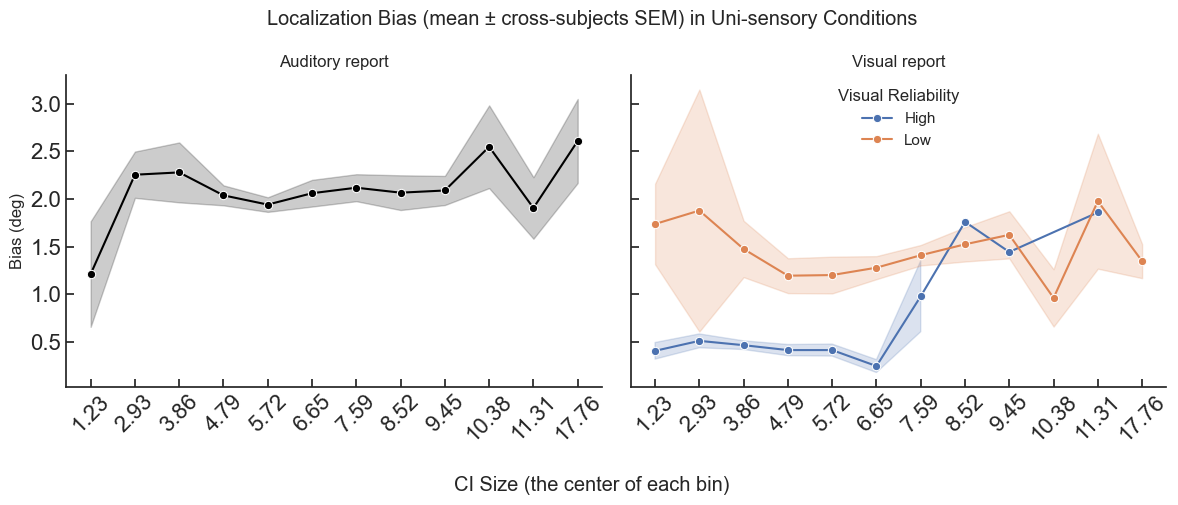

In [31]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_uni_avg_stim[df_uni_avg_stim['Modality']=='A'], x='CI Bin', y='mean', color = 'black', errorbar='se', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_uni_avg_stim[df_uni_avg_stim['Modality']=='V'], x='CI Bin', y='mean', hue='vislab', errorbar='se', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('Bias (deg)')
axs[1].set_title('Visual report')
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Uni-sensory Conditions')
plt.tight_layout()
plt.show()

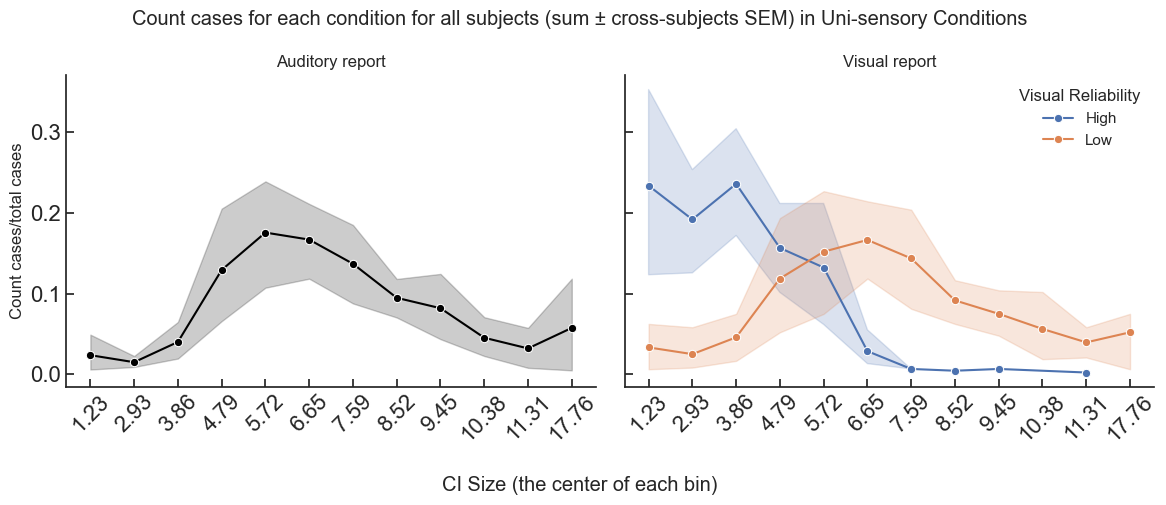

In [32]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_uni_avg_stim[df_uni_avg_stim['Modality']=='A'], x='CI Bin', color = 'black', y='count_reg', estimator='sum', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_uni_avg_stim[df_uni_avg_stim['Modality']=='V'], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('Count cases/total cases')
axs[1].set_title('Visual report')
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Count cases for each condition for all subjects (sum ± cross-subjects SEM) in Uni-sensory Conditions')
plt.tight_layout()
plt.show()

# Congruent trials

In [33]:
#data preparation
# Congruent trials
df_cong = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    # filter out the unisensory data
    sub_congA_data = subA_data.loc[(subA_data['Aud Loc'] == subA_data['Vis Loc'])].copy().reset_index(drop=True)
    sub_congV_data = subV_data.loc[(subV_data['Aud Loc'] == subV_data['Vis Loc'])].copy().reset_index(drop=True)
    sub_congA_data.loc[:,'sub_id'] = sub_id
    sub_congA_data.loc[:,'Modality'] = 'A'
    sub_congA_data.loc[:,'stim_loc'] = sub_congA_data['Aud Loc']
    sub_congV_data.loc[:,'sub_id'] = sub_id
    sub_congV_data.loc[:,'Modality'] = 'V'
    sub_congV_data.loc[:,'stim_loc'] = sub_congV_data['Vis Loc']

     # concatenate the data
    df_cong = pd.concat([df_cong, sub_congA_data, sub_congV_data], ignore_index=True)

In [34]:
df_cong

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc
0,1,6,-5.0,-5.0,1,-3.82,2.91,1.0,88.0,2,A,-5
1,1,15,0.0,0.0,1,0.00,3.14,1.0,100.0,2,A,0
2,1,16,-10.0,-10.0,1,-7.93,3.53,1.0,80.0,2,A,-10
3,1,17,10.0,10.0,1,7.05,3.98,1.0,59.0,2,A,10
4,1,22,5.0,5.0,1,4.82,3.57,1.0,80.0,2,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3880,4,151,-10.0,-10.0,2,-8.15,8.14,1.0,100.0,25,V,-10
3881,4,159,5.0,5.0,2,8.37,7.26,1.0,100.0,25,V,5
3882,4,163,10.0,10.0,2,8.81,7.45,1.0,92.0,25,V,10
3883,4,174,0.0,0.0,2,0.00,0.44,1.0,96.0,25,V,0


In [35]:
# get the perceptual bias
df_cong_stat = df_cong.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])['Resp Loc'].agg(['mean', 'std']).reset_index()
df_cong = pd.merge(df_cong, df_cong_stat, on=['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], how='left')
df_cong['bias'] = (df_cong['Resp Loc'] - df_cong['mean']).abs()

In [36]:
# deal with outliers for auditory, visual and two reliability levels separately
def remove_outliers(df):
    df = df.copy()
    df.loc[:,'bias_zscore'] = (df['bias'] - df['bias'].mean()) / df['bias'].std()
    df.loc[:,'CISize_zscore'] = (df['CI Size'] - df['CI Size'].mean()) / df['CI Size'].std()
    return df[(df.bias_zscore.abs() <= 3) & (df.CISize_zscore.abs() <= 3)]

df_cong_filter = (df_cong.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))

C:\Users\wenlou\AppData\Local\Temp\ipykernel_28908\400714820.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


In [37]:
# ci range
ci_bins = np.append(0, np.linspace(df_cong_filter['CI Size'].quantile(0.05), df_cong_filter['CI Size'].quantile(0.95), 11))  # 10 bins
ci_bins = np.append(ci_bins, df_cong_filter['CI Size'].max()+0.1)  # ensure the max value is included
df_cong_filter['CI Bin'] = pd.cut(df_cong_filter['CI Size'], bins=ci_bins, labels=False)
ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
df_cong_filter

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc,mean,std,bias,bias_zscore,CISize_zscore,CI Bin
0,1,16,-10.0,-10.0,1,-7.93,3.53,1.0,80.0,2,A,-10,-8.312162,1.111541,0.382162,-0.620428,-1.015708,2
1,1,76,-10.0,-10.0,1,-6.83,4.87,1.0,78.0,2,A,-10,-8.312162,1.111541,1.482162,0.898071,-0.212409,3
2,1,147,-10.0,-10.0,1,-7.82,4.42,1.0,47.0,2,A,-10,-8.312162,1.111541,0.492162,-0.468578,-0.482174,3
3,2,26,-10.0,-10.0,1,-9.25,4.59,1.0,67.0,2,A,-10,-8.312162,1.111541,0.937838,0.146657,-0.380263,3
4,2,154,-10.0,-10.0,1,-8.26,5.06,1.0,45.0,2,A,-10,-8.312162,1.111541,0.052162,-1.075977,-0.098509,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3793,3,94,10.0,10.0,2,7.82,14.71,2.0,100.0,25,V,10,7.770833,1.212641,0.049167,-1.113730,1.138776,11
3794,3,179,10.0,10.0,2,6.49,12.39,2.0,100.0,25,V,10,7.770833,1.212641,1.280833,0.496666,0.284694,11
3795,4,38,10.0,10.0,2,6.94,7.97,1.0,78.0,25,V,10,7.770833,1.212641,0.830833,-0.091706,-1.342480,7
3796,4,90,10.0,10.0,2,10.23,8.48,1.0,100.0,25,V,10,7.770833,1.212641,2.459167,2.037329,-1.154729,7


In [38]:
df_cong_filter.loc[:, 'cj']=2-df_cong_filter.loc[:, 'Sources']
df_cong_filter

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,Modality,stim_loc,mean,std,bias,bias_zscore,CISize_zscore,CI Bin,cj
0,1,16,-10.0,-10.0,1,-7.93,3.53,1.0,80.0,2,A,-10,-8.312162,1.111541,0.382162,-0.620428,-1.015708,2,1.0
1,1,76,-10.0,-10.0,1,-6.83,4.87,1.0,78.0,2,A,-10,-8.312162,1.111541,1.482162,0.898071,-0.212409,3,1.0
2,1,147,-10.0,-10.0,1,-7.82,4.42,1.0,47.0,2,A,-10,-8.312162,1.111541,0.492162,-0.468578,-0.482174,3,1.0
3,2,26,-10.0,-10.0,1,-9.25,4.59,1.0,67.0,2,A,-10,-8.312162,1.111541,0.937838,0.146657,-0.380263,3,1.0
4,2,154,-10.0,-10.0,1,-8.26,5.06,1.0,45.0,2,A,-10,-8.312162,1.111541,0.052162,-1.075977,-0.098509,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3793,3,94,10.0,10.0,2,7.82,14.71,2.0,100.0,25,V,10,7.770833,1.212641,0.049167,-1.113730,1.138776,11,0.0
3794,3,179,10.0,10.0,2,6.49,12.39,2.0,100.0,25,V,10,7.770833,1.212641,1.280833,0.496666,0.284694,11,0.0
3795,4,38,10.0,10.0,2,6.94,7.97,1.0,78.0,25,V,10,7.770833,1.212641,0.830833,-0.091706,-1.342480,7,1.0
3796,4,90,10.0,10.0,2,10.23,8.48,1.0,100.0,25,V,10,7.770833,1.212641,2.459167,2.037329,-1.154729,7,1.0


In [ ]:
# two step average:
# sources and the causal coonfidence
df_cong_avg = df_cong_filter.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc', 'CI Bin'], as_index=False).agg({'bias':['mean', 'count'], 'Conf Level':'mean', 'cj':'mean'}).reset_index()
df_cong_avg.columns = ['_'.join(col).strip() if col[1] else col[0]

,index,sub_id,Modality,Vis Rel,stim_loc,CI Bin,bias_mean,bias_count,Conf Level_mean,cj_mean
0,0,2,A,1,-10,0,0.167838,1,45.000000,1.000000
1,1,2,A,1,-10,2,0.626432,5,55.400000,1.000000
2,2,2,A,1,-10,3,0.643086,12,72.750000,0.916667
3,3,2,A,1,-10,4,0.666641,7,70.857143,1.000000
4,4,2,A,1,-10,5,0.741081,4,59.750000,1.000000
...,...,...,...,...,...,...,...,...,...,...
845,845,25,V,2,10,6,1.039167,1,92.000000,1.000000
846,846,25,V,2,10,7,1.645000,2,89.000000,1.000000
847,847,25,V,2,10,8,1.170833,1,100.000000,1.000000
848,848,25,V,2,10,10,0.830833,1,90.000000,1.000000


In [ ]:
 for col in df_cong_avg.columns.values]
df_cong_avg

In [40]:
df_cong_avg_stim = df_cong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'CI Bin']).agg({'bias_mean':'mean', 'bias_count':'sum', 'Conf Level_mean':'mean', 'cj_mean':'mean'}).reset_index()
df_cong_avg_stim

,sub_id,Modality,Vis Rel,CI Bin,bias_mean,bias_count,Conf Level_mean,cj_mean
0,2,A,1,0,0.149558,12,61.909091,1.000000
1,2,A,1,1,0.548619,17,64.694444,0.916667
2,2,A,1,2,0.610678,26,62.170000,1.000000
3,2,A,1,3,0.630362,51,58.452308,0.862949
4,2,A,1,4,0.631320,40,56.236349,0.905556
...,...,...,...,...,...,...,...,...
246,25,V,2,7,1.404167,4,67.666667,1.000000
247,25,V,2,8,0.875694,6,60.666667,1.000000
248,25,V,2,9,0.695741,5,49.777778,1.000000
249,25,V,2,10,0.619306,9,80.416667,0.916667


In [41]:
sum_count = df_cong_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['bias_count'].sum()
df_cong_avg_stim = pd.merge(df_cong_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_cong_avg_stim['count_reg'] = df_cong_avg_stim['bias_count'] / df_cong_avg_stim['bias_count_total']   # convert to percentage
df_cong_avg_stim['vislab'] = df_cong_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})
df_cong_avg_stim

,sub_id,Modality,Vis Rel,CI Bin,bias_mean,bias_count,Conf Level_mean,cj_mean,bias_count_total,count_reg,vislab
0,2,A,1,0,0.149558,12,61.909091,1.000000,1399,0.008578,High
1,2,A,1,1,0.548619,17,64.694444,0.916667,1399,0.012152,High
2,2,A,1,2,0.610678,26,62.170000,1.000000,1399,0.018585,High
3,2,A,1,3,0.630362,51,58.452308,0.862949,1399,0.036455,High
4,2,A,1,4,0.631320,40,56.236349,0.905556,1399,0.028592,High
...,...,...,...,...,...,...,...,...,...,...,...
246,25,V,2,7,1.404167,4,67.666667,1.000000,478,0.008368,Low
247,25,V,2,8,0.875694,6,60.666667,1.000000,478,0.012552,Low
248,25,V,2,9,0.695741,5,49.777778,1.000000,478,0.010460,Low
249,25,V,2,10,0.619306,9,80.416667,0.916667,478,0.018828,Low


In [42]:
df_cong_avg_stim.loc[(df_cong_avg_stim['Modality']=='A') & (df_cong_avg_stim['Vis Rel']==2), 'CI Bin'].describe()

count    71.000000
mean      6.000000
std       2.937443
min       0.000000
25%       4.000000
50%       6.000000
75%       8.000000
max      11.000000
Name: CI Bin, dtype: float64

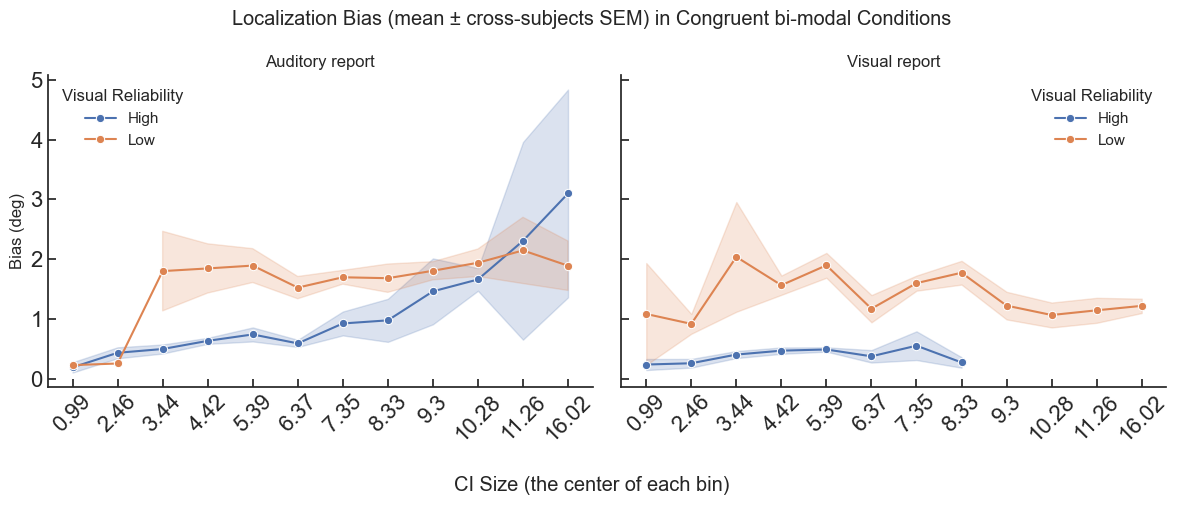

In [43]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='A'], x='CI Bin', y='bias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='V'], x='CI Bin', y='bias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('Bias (deg)')
axs[1].set_title('Visual report')
axs[0].legend(title='Visual Reliability', frameon=False)
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

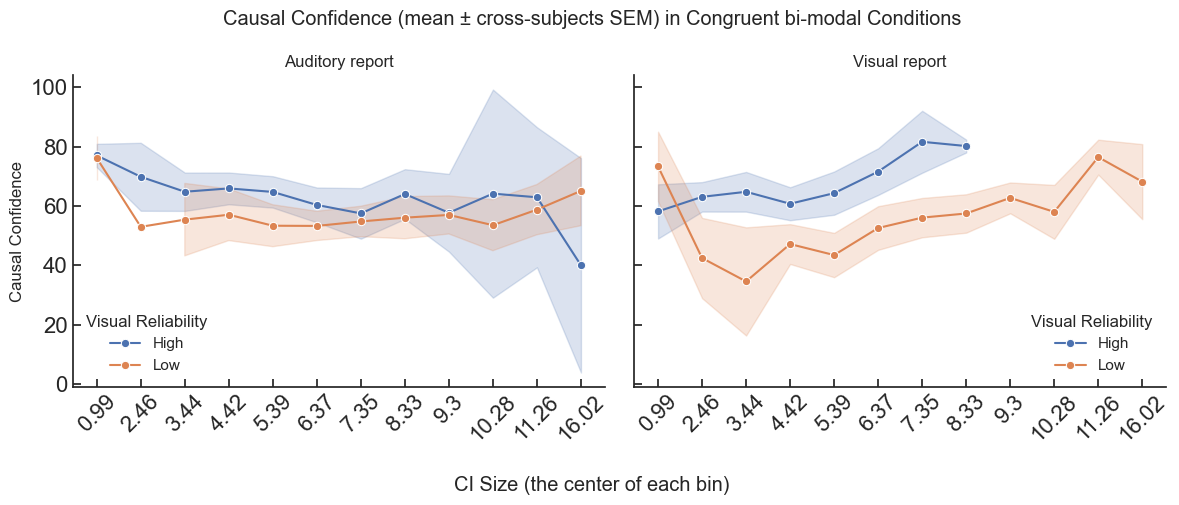

In [44]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='A'], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='V'], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('Causal Confidence')
axs[1].set_title('Visual report')
axs[0].legend(title='Visual Reliability', frameon=False)
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal Confidence (mean ± cross-subjects SEM) in Congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

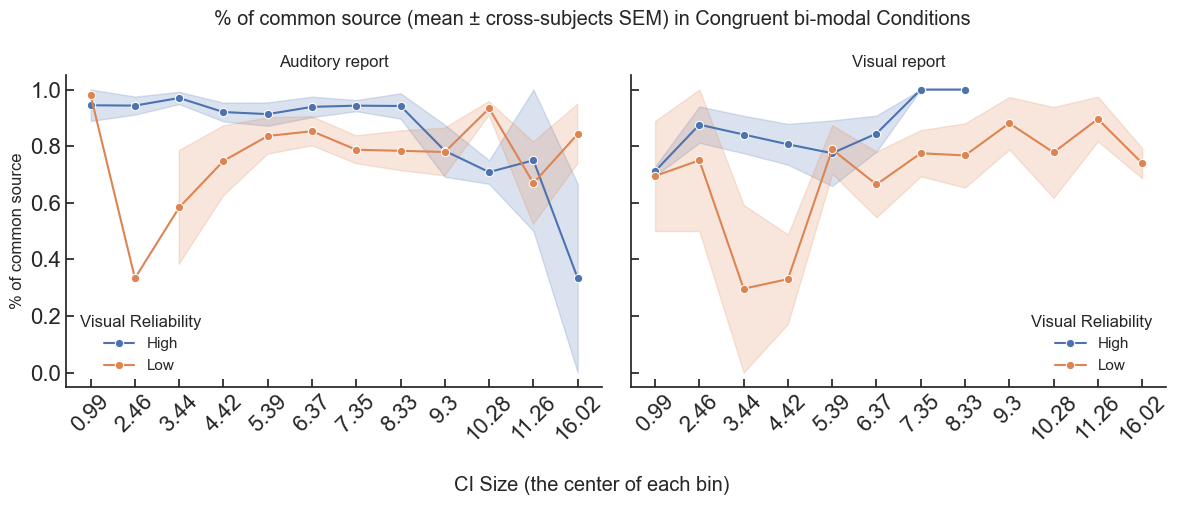

In [45]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='A'], x='CI Bin', y='cj_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='V'], x='CI Bin', y='cj_mean', hue='vislab', errorbar='se', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('% of common source')
axs[1].set_title('Visual report')
axs[0].legend(title='Visual Reliability', frameon=False)
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('% of common source (mean ± cross-subjects SEM) in Congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

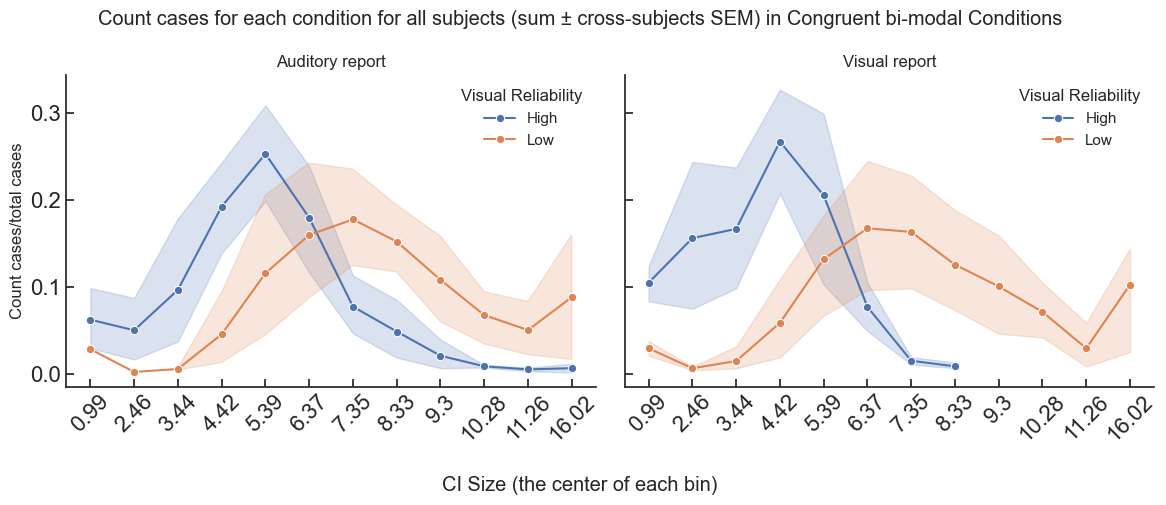

In [46]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# auditory
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='A'], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[0])
# visual
sns.lineplot(data=df_cong_avg_stim[df_cong_avg_stim['Modality']=='V'], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1])
for ax in axs:
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0].set_title('Auditory report')
axs[0].set_ylabel('Count cases/total cases')
axs[1].set_title('Visual report')
axs[0].legend(title='Visual Reliability', frameon=False)
axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Count cases for each condition for all subjects (sum ± cross-subjects SEM) in Congruent bi-modal Conditions')
plt.tight_layout()
plt.show()

# Incongruent trials

In [16]:
#data preparation
# Congruent trials
df = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    # filter out the unisensory data
    #sub_incongA_data = subA_data.loc[(subA_data['Aud Loc'] != subA_data['Vis Loc'])].copy().reset_index(drop=True)
    #sub_incongV_data = subV_data.loc[(subV_data['Aud Loc'] != subV_data['Vis Loc'])].copy().reset_index(drop=True)
    subA_data.loc[:,'sub_id'] = sub_id
    subA_data.loc[:,'Modality'] = 'A'
    subV_data.loc[:,'sub_id'] = sub_id
    subV_data.loc[:,'Modality'] = 'V'
    subV_data.loc[:,'stim_loc'] = subV_data['Vis Loc']
    subA_data.loc[:,'stim_loc'] = subA_data['Aud Loc']

    # concatenate the data
    df = pd.concat([df, subA_data, subV_data], ignore_index=True)

In [17]:
df_incong =  df.loc[df['Aud Loc'] != df['Vis Loc']].copy().reset_index(drop=True)

In [18]:
# get the perceptual bias
df_stat = df.groupby(['sub_id', 'Modality', 'Vis Rel', 'stim_loc'])['Resp Loc'].agg(['mean', 'std']).reset_index()
df_incong = pd.merge(df_incong, df_stat, on=['sub_id', 'Modality', 'Vis Rel', 'stim_loc'], how='left')
df_incong['bias'] = df_incong['Resp Loc'] - df_incong['mean']

In [19]:
#flip bias
df_incong['delta_VA'] = df_incong['Vis Loc'] - df_incong['Aud Loc']

#flip the bias
df_incong['flipBias'] = df_incong['bias'].copy()
df_incong.loc[df_incong['delta_VA']<0, 'flipBias'] = -df_incong.loc[df_incong['delta_VA']<0, 'flipBias']
df_incong['abs_delta_VA'] = df_incong.delta_VA.abs()

In [20]:
# deal with outliers for auditory, visual and two reliability levels separately
def remove_outliers(df):
    df = df.copy()
    df.loc[:,'bias_zscore'] = (df['flipBias'] - df['flipBias'].mean()) / df['flipBias'].std()
    df.loc[:,'CISize_zscore'] = (df['CI Size'] - df['CI Size'].mean()) / df['CI Size'].std()
    return df[(df.bias_zscore.abs() <= 3) & (df.CISize_zscore.abs() <= 3)]

df_incong = (df_incong.groupby(['sub_id', 'Modality', 'Vis Rel', 'Vis Loc', 'Aud Loc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))

C:\Users\wenlou\AppData\Local\Temp\ipykernel_15680\3174230577.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


In [21]:
# ci range
ci_bins = np.append(0, np.linspace(df_incong['CI Size'].quantile(0.05), df_incong['CI Size'].quantile(0.95), 11))  # 10 bins
ci_bins = np.append(ci_bins, df_incong['CI Size'].max()+0.1)  # ensure the max value is included
df_incong['CI Bin'] = pd.cut(df_incong['CI Size'], bins=ci_bins, labels=False)
ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
df_incong

,Block Nr,Trial Nr,Aud Loc,Vis Loc,Vis Rel,Resp Loc,CI Size,Sources,Conf Level,sub_id,...,stim_loc,mean,std,bias,delta_VA,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,CI Bin
0,1,4,-5.0,-10.0,1,-5.94,5.56,1.0,39.0,2,...,-5,-1.448559,4.960467,-4.491441,-5.0,4.491441,5.0,-1.339457,0.379960,4
1,1,87,-5.0,-10.0,1,-7.05,3.32,2.0,80.0,2,...,-5,-1.448559,4.960467,-5.601441,-5.0,5.601441,5.0,-0.383732,-1.438233,1
2,1,141,-5.0,-10.0,1,-6.27,4.66,1.0,47.0,2,...,-5,-1.448559,4.960467,-4.821441,-5.0,4.821441,5.0,-1.055323,-0.350564,3
3,2,1,-5.0,-10.0,1,-9.03,4.83,1.0,69.0,2,...,-5,-1.448559,4.960467,-7.581441,-5.0,7.581441,5.0,1.321073,-0.212576,3
4,2,101,-5.0,-10.0,1,-9.69,6.12,1.0,69.0,2,...,-5,-1.448559,4.960467,-8.241441,-5.0,8.241441,5.0,1.889341,0.834509,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15276,3,106,5.0,10.0,2,8.92,12.24,1.0,18.0,25,...,10,7.752639,1.053474,1.167361,5.0,1.167361,5.0,0.895224,0.251635,11
15277,3,164,5.0,10.0,2,7.60,15.37,2.0,10.0,25,...,10,7.752639,1.053474,-0.152639,5.0,-0.152639,5.0,-0.318847,1.716971,11
15278,4,45,5.0,10.0,2,10.12,9.14,1.0,100.0,25,...,10,7.752639,1.053474,2.367361,5.0,2.367361,5.0,1.998925,-1.199656,8
15279,4,72,5.0,10.0,2,6.94,7.75,2.0,100.0,25,...,10,7.752639,1.053474,-0.812639,5.0,-0.812639,5.0,-0.925882,-1.850396,6


In [22]:
df_incong_avg = df_incong.groupby(['sub_id', 'Modality', 'Vis Rel', 'abs_delta_VA', 'Sources', 'CI Bin'], as_index=False).agg({'flipBias':['mean', 'count'], 'Conf Level':'mean'}).reset_index()
df_incong_avg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_incong_avg.columns.values]

df_incong_avg_stim = df_incong_avg.groupby(['sub_id', 'Modality', 'Vis Rel', 'Sources', 'CI Bin']).agg({'flipBias_mean':'mean', 'flipBias_count':'sum', 'Conf Level_mean':'mean'}).reset_index()
df_incong_avg_stim

,sub_id,Modality,Vis Rel,Sources,CI Bin,flipBias_mean,flipBias_count,Conf Level_mean
0,2,A,1,1.0,0,3.866880,29,71.329167
1,2,A,1,1.0,1,8.091768,54,45.429534
2,2,A,1,1.0,2,6.791412,84,47.727716
3,2,A,1,1.0,3,7.559187,88,54.737666
4,2,A,1,1.0,4,6.306645,53,52.212963
...,...,...,...,...,...,...,...,...
564,25,V,2,2.0,7,-0.087991,19,64.226190
565,25,V,2,2.0,8,0.840162,8,34.333333
566,25,V,2,2.0,9,0.085035,12,62.375000
567,25,V,2,2.0,10,-0.414556,15,66.716667


In [23]:
sum_count = df_incong_avg_stim.groupby(['Modality', 'Vis Rel'], as_index=False)['flipBias_count'].sum()
df_incong_avg_stim = pd.merge(df_incong_avg_stim, sum_count, on=['Modality', 'Vis Rel'], suffixes=('', '_total'))
df_incong_avg_stim['count_reg'] = df_incong_avg_stim['flipBias_count'] / df_incong_avg_stim['flipBias_count_total']   # convert to percentage
df_incong_avg_stim['vislab'] = df_incong_avg_stim['Vis Rel'].map({1:'High', 2:'Low'})

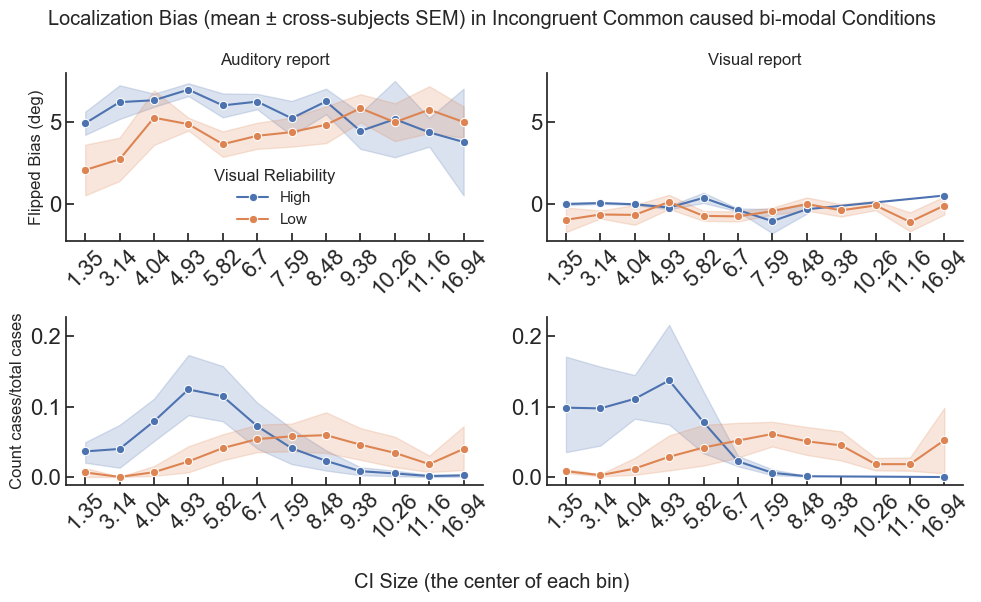

In [31]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Incongruent Common caused bi-modal Conditions')
plt.tight_layout()
plt.show()

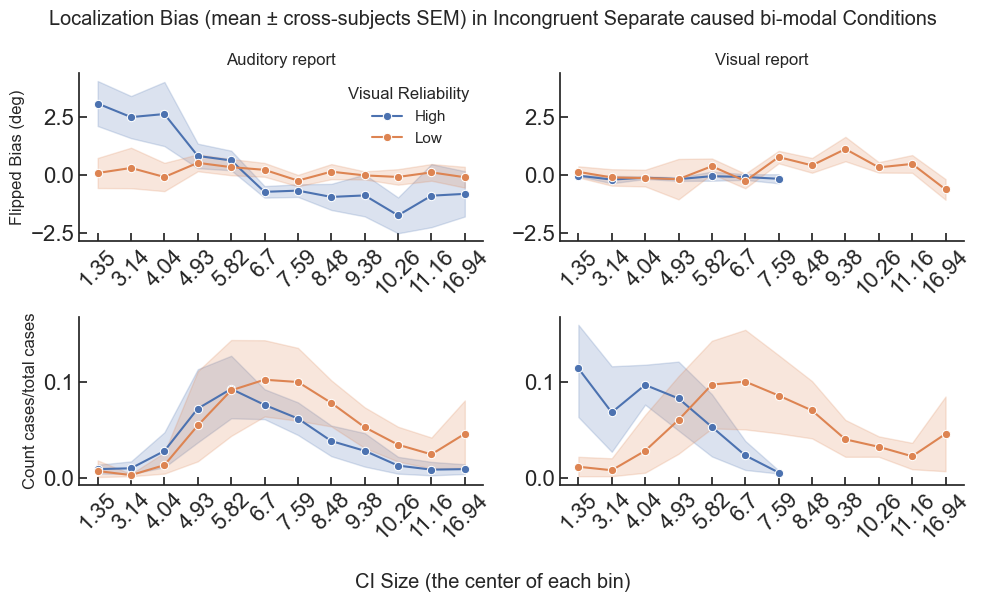

In [32]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='flipBias_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Flipped Bias (deg)')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Localization Bias (mean ± cross-subjects SEM) in Incongruent Separate caused bi-modal Conditions')
plt.tight_layout()
plt.show()

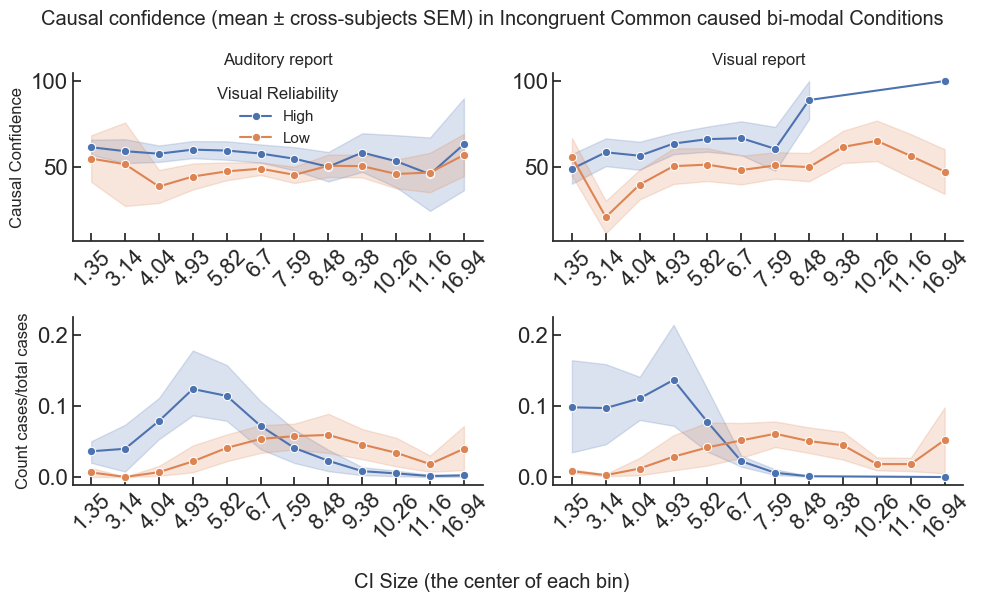

In [36]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==1)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Causal Confidence')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal confidence (mean ± cross-subjects SEM) in Incongruent Common caused bi-modal Conditions')
plt.tight_layout()
plt.show()

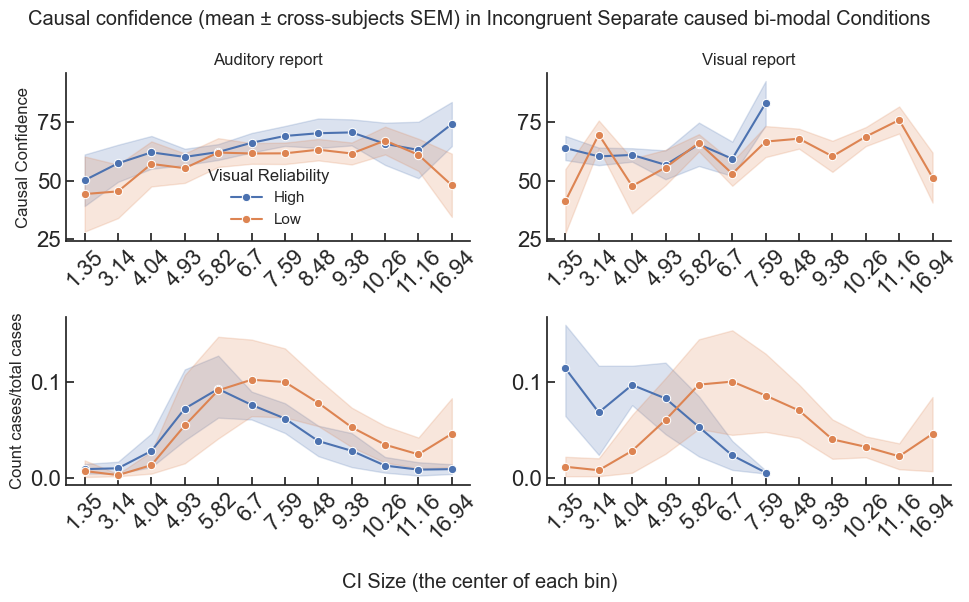

In [35]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# share y-axis within each row manually
for row in axs:
    row[1].sharey(row[0])  # share y between left and right subplot in the same row

# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 0])
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='Conf Level_mean', hue='vislab', errorbar='se', marker='o', ax = axs[0, 1],legend=None)
# auditory
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='A')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', hue='vislab', y='count_reg', estimator='sum', marker='o', ax = axs[1,0],legend=None)
# visual
sns.lineplot(data=df_incong_avg_stim[(df_incong_avg_stim['Modality']=='V')&(df_incong_avg_stim['Sources']==2)], x='CI Bin', y='count_reg', hue='vislab', estimator='sum', marker='o', ax = axs[1,1],legend=None)

for ax in axs.flatten():
    clean_axs(ax)
    ax.set_xticks(range(len(ci_labels)))
    ax.set_xticklabels([round(x, 2) for x in ci_labels], rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.legend('')
fig.supxlabel('CI Size (the center of each bin)')
axs[0,0].set_title('Auditory report')
axs[0,0].set_ylabel('Causal Confidence')
axs[0,1].set_title('Visual report')
axs[1,0].set_ylabel('Count cases/total cases')
axs[0,0].legend(title='Visual Reliability', frameon=False)
#axs[1].legend(title='Visual Reliability', frameon=False)
fig.suptitle('Causal confidence (mean ± cross-subjects SEM) in Incongruent Separate caused bi-modal Conditions')
plt.tight_layout()
plt.show()